<div style="
    font-family: 'Poppins', sans-serif;
    background-color: #003366;
    color: white;
    width: 700px;
    padding: 50px;
    border-radius: 25px;
    margin: 40px auto;
    box-shadow: 0 8px 16px rgba(0, 0, 0, 0.4);
    text-align: center;
">
    <h1 style="font-size: 42px; margin-bottom: 25px;">Jose Carlos Fernandez</h1>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Matrícula:</strong> 2024-0371</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Fecha:</strong> 26/06/2025</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Maestro:</strong> Esloboan Mora</p>
    <p style="font-size: 24px; margin: 15px 0;"><strong>Materia:</strong> Analitca descriptiva 3</p>
    
</div>


# **Asignación 3. Programación entera Modelos de transporte y asignación.**

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Problema 1️⃣**

### **Puntos clave del problema:**

- **Es un problema de asignación binaria donde:**

- **Hay 5 profesores (A, B, C, D, E).**

- **Hay 10 materias.**

- **Cada profesor debe dictar 2 materias.**

- **Cada materia debe ser asignada a un solo profesor.**

- **Algunos profesores no pueden dictar ciertas materias (valor = 0).**

- **El objetivo es maximizar la suma de preferencias (satisfacción).**

**Primero que todo, importamos la libreria que nos permite trabajar con problemas de programacion entera, la cual es `pulp`**

In [7]:
import pulp

**Ahora definimos nuestros datos, los cuales son:**

- *Los profesores son A, B, C, D y E.*
- *Las materias son 10, con las preferencias dadas en la tabla.*

**Entonces ahora si podemos empezar codificar nuestro problema...**

**Creemos 2 listas**

- *Profesores: la cual tendra los nombres de los profesores*
- *Materias: la cual tendra los nombres de las materias*

In [8]:
profesores = ['A', 'B', 'C', 'D', 'E']
materias = [
    "Optimización 1", "Optimización 2", "Simulación", "Sistemas de apoyo",
    "Ingeniería de Software", "Informática creativa", "Estructura de datos",
    "Computación emergente", "Bases de datos", "Ingeniería Económica"
]

**Ahora creamos la tabla que esta en el problema, teniendo en cuenta que:**

- *Las filas representan las materias*
- *Las columnas representan los profesores*

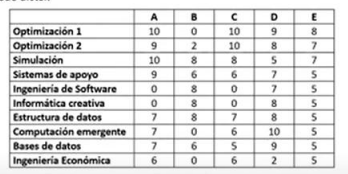

In [9]:
satisfaccion = [
    [10, 0, 10, 9, 8],  # Opt 1
    [9, 2, 10, 8, 7],   # Opt 2
    [10, 8, 8, 5, 7],   # Simulación
    [9, 6, 6, 7, 5],    # Sist. apoyo
    [0, 8, 0, 7, 5],  # Ing. Software
    [0, 8, 0, 8, 5],    # Inf. creativa
    [7, 8, 7, 8, 5],    # Estructura de datos
    [7, 0, 6, 10, 5],    # Comp. emergente
    [7, 6, 5, 9, 5],   # Bases de datos
    [6, 0, 6, 2, 5]     # Ing. Económica
]

**Posteriormente creamos lo que es el modelo, indicandole que Maximice la operacion.**

**Puntos clave:**

- *`i` es la **materia***
- *`j` es el **profesor***
- *Categorizamos al tipo `Binario` e iteramos por todos los profesores y materias de la tabla ya creada*

In [10]:
# Creacion de el modelo
modelo = pulp.LpProblem("Asignacion_de_materias", pulp.LpMaximize)

# Variables binarias x[i][j]: 1 si materia i es asignada a profesor j
x = [
    [pulp.LpVariable(f"x_{i}_{j}", cat="Binary") for j in range(len(profesores))]
    for i in range(len(materias))
]

# Función objetivo: maximizar la satisfacción total
modelo += pulp.lpSum(satisfaccion[i][j] * x[i][j] for i in range(10) for j in range(5))

**Restricciones:**

- 1️⃣*cada materia se asigna a un solo profesor*
- 2️⃣*cada profesor debe tener exactamente 2 materias*
- 3️⃣*no asignar materia si tiene 0 de satisfacción*

In [11]:
# 1️⃣
for i in range(10):
    modelo += pulp.lpSum(x[i][j] for j in range(5)) == 1

# 2️⃣
for j in range(5):
    modelo += pulp.lpSum(x[i][j] for i in range(10)) == 2

# 3️⃣
for i in range(10):
    for j in range(5):
        if satisfaccion[i][j] == 0:
            modelo += x[i][j] == 0

**Resultados:**

In [12]:
modelo.solve()

# Muestreo de los resultados
print("Asignaciones optimas:")
for i in range(10):
    for j in range(5):
        if x[i][j].varValue == 1:
            print(f"{materias[i]} al Profesor {profesores[j]}")

print(f"\nSatisfaccion total: {pulp.value(modelo.objective)}")

Asignaciones optimas:
Optimización 1 al Profesor C
Optimización 2 al Profesor C
Simulación al Profesor A
Sistemas de apoyo al Profesor A
Ingeniería de Software al Profesor E
Informática creativa al Profesor B
Estructura de datos al Profesor B
Computación emergente al Profesor D
Bases de datos al Profesor D
Ingeniería Económica al Profesor E

Satisfaccion total: 84.0


<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Problema 2️⃣**

### **Puntos clave del problema:**

- **Es un problema de programación entera binaria:**

**Productos: 4 (Artículo 1, 2, 3, 4).**

- **No se pueden producir más de dos de estos productos.**
- **El producto 3 se puede producir sólo si se produce cualquiera de los productos 1 ó 2.**
- **Se dispone de $200 de capital total para invertir en estos proyectos.**
- **Las oportunidades de inversión 3 y 4 son mutuamente excluyentes.**

---

**Variables de decisión:**

- **x1, x2, x3, x4 pertenecen a {0, 1} ➡ `1` si se produce ese artículo, `0` si no.**

- **Maximizar utilidad total decidiendo que artículos deben llevarse a producción.**

---

**Funcion Objetivo:**
- **Maximizar utilidad total**
- 70*x1 + 60*x2 + 90*x3 + 80*x4

---


**Creamos el modelo en primer lugar**

In [13]:
modelo = pulp.LpProblem("Seleccion_de_productos", pulp.LpMaximize)

**Creamos las variables binarias para cada articulo**

In [14]:
x1 = pulp.LpVariable("x1", cat="Binary")
x2 = pulp.LpVariable("x2", cat="Binary")
x3 = pulp.LpVariable("x3", cat="Binary")
x4 = pulp.LpVariable("x4", cat="Binary")

**Funcion objetivo para maximizar la utilidad:**

In [15]:
modelo += 70*x1 + 60*x2 + 90*x3 + 80*x4

**Definimos nuestras restricciones:**

- *Restricción 1: máximo dos productos*
- *Restricción 2: el producto 3 solo se puede producir si se produce el 1 o el 2*
- *Restricción 3: capital máximo $200*
- *Restricción 4: productos 3 y 4 son mutuamente excluyentes*

In [16]:
# 1️⃣
modelo += x1 + x2 + x3 + x4 <= 2

# 2️⃣
modelo += x3 <= x1 + x2

# 3️⃣
modelo += 55*x1 + 40*x2 + 76*x3 + 68*x4 <= 200

# 4️⃣
modelo += x3 + x4 <= 1

**Muestreo de los resultados**

In [17]:
modelo.solve()

# Muestreo de resultados
print("Articulos a producir:")
for var in [x1, x2, x3, x4]:
    if var.varValue == 1:
        print(f"- {var.name}")

print(f"\nUtilidad total máxima: {pulp.value(modelo.objective)}")

Articulos a producir:
- x1
- x3

Utilidad total máxima: 160.0


**📌 ¿Qué hace el modelo?**

**El modelo elige hasta 2 productos, de forma que:**

- *No se pasen de $200 en costo total.*

- *No elija ambos productos 3 y 4 a la vez.*

- *Si elige el producto 3, debe elegir también el 1 o el 2.*

- *Y maximiza la suma de las utilidades de los productos elegidos.*

**💲 Entonces:**

*La utilidad total máxima es el valor que se obtiene al sumar las utilidades de los productos seleccionados por el modelo.*

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Problema 3️⃣**

### **📌 Definición breve del problema**

**Un distribuidor desea alquilar uno o varios almacenes (A, B y/o C) para satisfacer la demanda de camiones en 4 distritos. Cada almacén tiene:**

- *Un costo fijo mensual de alquiler*

- *Una capacidad máxima de envío de camiones*

- *Un costo por enviar un camión a cada distrito*

El objetivo es:

    Determinar qué almacenes alquilar y cómo distribuir los camiones desde esos almacenes a los distritos para minimizar el costo total (alquiler + transporte).

### **🧠 Decisiones que hay que tomar:**

**Variables binarias `y[i]`:**

- *`yA` = 1 si se alquila el almacén A, 0 si no.*

- *Igual para B y C.*

**Variables enteras `x[i][j]`:**

- *Número de camiones enviados desde el almacén `i` al distrito `j`.*

**Bueno, entendido eso hagamos entonces los conjuntos:**

In [18]:
almacenes = ['A', 'B', 'C']
distritos = [1, 2, 3, 4]

**Entonces asignemosle los datos a dichos conjuntos:**

In [19]:
costo_envio = {
    'A': [170, 40, 70, 160],
    'B': [150, 195, 100, 10],
    'C': [100, 240, 140, 60]
}

capacidad = {'A': 200, 'B': 250, 'C': 300}
alquiler = {'A': 7750, 'B': 4000, 'C': 5500}
demanda = [100, 90, 110, 60]

**👁Esto es con la intencion de que nuestros datos queden estructurados como la tabla del ejercicio:**

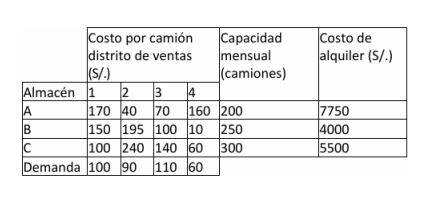

**Listo, ahora creamos nuestro modelo:**

In [21]:
modelo = pulp.LpProblem("Distribucion_optima_de_camiones", pulp.LpMinimize) # Minimizamos porque eso es lo que nos piden

**Luego, hacemos nuestras variables `x, y` donde:**

- *`x` representa los camiones para distribuir*
- *`y` representa si vamos a alquilar el almacen o no, o sea, `Binario` (SI o NO)*

In [22]:
# Variables de decisión
x = pulp.LpVariable.dicts("camiones", [(i, j) for i in almacenes for j in distritos], lowBound=0, cat='Integer')
y = pulp.LpVariable.dicts("alquilar", almacenes, cat='Binary')

**Ahora podemos hacer la funcion ojetivo... pero cabe destacar que:**

- *Se va a hacer para minimzar el costo total*
- *Se va a calcular el `envio` + el `alquiler`, o sea, la función objetivo tiene dos componentes clave porque en este problema hay dos tipos de costos que queremos minimizar al mismo tiempo*
- *Basicamente se veria asi: **`modelo` += `transporte_total` + `alquiler_total`***

In [23]:
# Función objetivo: minimizar costo total (envío + alquiler)
modelo += (
    pulp.lpSum(costo_envio[i][j-1] * x[(i, j)] for i in almacenes for j in distritos)  # Costo de envío
    + pulp.lpSum(alquiler[i] * y[i] for i in almacenes)  # Costo de alquiler
)

**Restricciones:**

- *Restricción 1: cubrir la demanda de cada distrito*
- *Restricción 2: no exceder la capacidad mensual de cada almacén*

In [25]:
# 1️⃣
for j in distritos:
    modelo += pulp.lpSum(x[(i, j)] for i in almacenes) == demanda[j - 1]

# 2️⃣
for i in almacenes:
    modelo += pulp.lpSum(x[(i, j)] for j in distritos) <= capacidad[i] * y[i]

**Resultados:**

In [28]:
modelo.solve()

# Muestreo de resultados
print("Almacenes a alquilar:")
for i in almacenes: # Mostramos los almacenes que se alquilarán
    if y[i].varValue == 1:
        print(f"- Almacén {i}")

print("\nPlan de distribución:")
for i in almacenes: # Mostramos el plan de distribución
    for j in distritos:
        cantidad = x[(i, j)].varValue # Cantidad de camiones asignados 
        if cantidad > 0: # Solo mostrar si hay camiones asignados
            print(f"{cantidad:.0f} camiones de almacén {i} al distrito {j}")

print(f"\nCosto total mínimo: 💲{pulp.value(modelo.objective):,.2f}") # Mostramos el costo total mínimo con formato de moneda

Almacenes a alquilar:
- Almacén A
- Almacén C

Plan de distribución:
90 camiones de almacén A al distrito 2
110 camiones de almacén A al distrito 3
100 camiones de almacén C al distrito 1
60 camiones de almacén C al distrito 4

Costo total mínimo: 💲38,150.00


**📌 ¿Qué hace el código?**

**Minimiza:**

- *El costo de transporte de camiones + el costo de alquilar almacenes.*

**Respeta:**

- *Toda la demanda de los distritos.*
- *La capacidad máxima de cada almacén solo si está alquilado.*

<hr style="
    border: none;
    border-top: 15px solid #003366;
    border-radius: 8px;
    width: 80%;
    margin: 80px auto;
">

## **Problema 4️⃣**

### **📌 Definición breve del problema**

**Una constructora debe seleccionar 4 de 6 proyectos a realizar, buscando maximizar el beneficio total, pero cumpliendo varias restricciones lógicas entre proyectos.**

**Cada proyecto tiene un beneficio (en miles de $):**
| Proyecto      | Beneficio |
| ------------- | --------- |
| Camino        | 50        |
| Supermercado  | 60        |
| Casas         | 70        |
| Departamentos | 80        |
| Parques       | 90        |
| Puentes       | 50        |



**✅ Variables de decisión**

**Variables binarias:**

- *`xCamino = 1` si se hace el proyecto Camino, `0 si no`.*
- *Igual para los demás proyectos.*

**Creemos el modelo para maximizar el beneficio total:**

In [29]:
modelo = pulp.LpProblem("Seleccion_de_proyectos", pulp.LpMaximize)

**Entonces ahora vamos a hacer las variables binarias:**

- *`Proyectos` que la lista de proyectos de la constructora*
- *`x` que va a representar la misma variable pero de tipo binario*

In [30]:
proyectos = ['Camino', 'Supermercado', 'Casas', 'Departamentos', 'Parques', 'Puentes']
x = pulp.LpVariable.dicts("x", proyectos, cat="Binary")

**Ahora codificamos la tabla de beneficios justo como esta en el ejemplo:**

In [31]:
# Beneficios
beneficio = {
    'Camino': 50,
    'Supermercado': 60,
    'Casas': 70,
    'Departamentos': 80,
    'Parques': 90,
    'Puentes': 50
}

**Ahora solo queda hacer la funcion objetivo:**

In [32]:
# maximizar beneficio total
modelo += pulp.lpSum(beneficio[p] * x[p] for p in proyectos)

**⚙️ Restricciones reescritas en forma algebraica**

- 1️⃣ **Si se hace el Supermercado, entonces se debe hacer el Camino** (`xSupermercado <= xCamino`)
- 2️⃣ **Se puede hacer como máximo uno entre Camino y Departamentos** (`xCamino + xDepartamentos <= 1`)
- 3️⃣ **Si se hace Casas, entonces se debe hacer al menos uno entre Departamentos o Parques** (`xCasas <= xDepartamentos + xParques`)
- 4️⃣ **Se deben hacer exactamente 4 proyectos** (`xCamino + xSupermercado + xCasas + xDepartamentos + xParques + xPuentes = 4`)
- 5️⃣ **Si se hace Departamentos, entonces también se debe hacer Casas** (`xDepartamentos <= xCasas`)
- 6️⃣ **No se pueden hacer simultáneamente Departamentos y Puentes** (`xDepartamentos + xPuentes <= 1`)

In [33]:
# 1️⃣
modelo += x['Supermercado'] <= x['Camino']

# 2️⃣
modelo += x['Camino'] + x['Departamentos'] <= 1

# 3️⃣
modelo += x['Casas'] <= x['Departamentos'] + x['Parques']

# 4️⃣
modelo += pulp.lpSum(x[p] for p in proyectos) == 4

# 5️⃣
modelo += x['Departamentos'] <= x['Casas']

# 6️⃣
modelo += x['Departamentos'] + x['Puentes'] <= 1

**Resultados:**

In [35]:
modelo.solve()

# Muestreo de resultados
print("Proyectos seleccionados:")
for p in proyectos: # Iteramos sobre los proyectos
    if x[p].varValue == 1: # Solo mostrar si el proyecto está seleccionado
        print(f"- {p}") # Mostramos el proyecto seleccionado

print(f"\nBeneficio total máximo: {pulp.value(modelo.objective)} miles de $") # Mostramos el beneficio total máximo

Proyectos seleccionados:
- Camino
- Supermercado
- Casas
- Parques

Beneficio total máximo: 270.0 miles de $


**📌 ¿Qué hace el código?**

**El código seleccionará los 4 proyectos que cumplan todas las reglas lógicas y den el mayor beneficio total posible.**

<div style="display: flex; justify-content: center; align-items: center; height: 300px;">
    <div style="background-color: #28a745; color: white; width: 600px; height: 300px; border-radius: 30px; box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2); font-size: 64px; font-weight: bold; text-align: center; display: flex; justify-content: center; align-items: center;">
        FIN
        <p style="position: absolute; bottom: 15px; font-size: 14px; color: #ddd;">Jose Carlos Fernandez</p>
    </div>
</div>
